In [1]:
import pandas as pd
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt

In [31]:
gdf = gpd.read_file('../inputs/ar_seawulf.gpkg')
with open('../outputs/ar_250.pkl', 'rb') as file:
    raceblind_pickle = pickle.load(file)
with open('../outputs/ar_vra_5000.pkl', 'rb') as file:
    vra_pickle = pickle.load(file)

# Preprocessing & Background needed:
- each plan assignment has the redistrcting of all precincts
- the format is in (x,y) where 
    - x = node_idx 
    - y = new_assigned_distrcit
- to perform analysis -> we have to get the UNIQUE_ID of each of this distrcts for better visualization and mapping

In [32]:
node_to_id = gdf['Unique_ID'].to_dict()

In [33]:
gdf = gdf.rename(columns={'Unique_ID': 'UNIQUE_ID'})

In [34]:
raceblind_plans = []
for plan in raceblind_pickle:
    df = pd.DataFrame(plan.items(), columns=['node_id', 'District'])
    df['UNIQUE_ID'] = df['node_id'].map(node_to_id)
    df = df[['UNIQUE_ID', 'District']]
    raceblind_plans.append(df)

In [35]:
vra_plans = []
for plan in vra_pickle:
    df = pd.DataFrame(plan.items(), columns=['node_id', 'District'])
    df['UNIQUE_ID'] = df['node_id'].map(node_to_id)
    df = df[['UNIQUE_ID', 'District']]
    vra_plans.append(df)

# Calculate election winners
- Using 2024 statewide presidential results, estimate the election results in each district of each ensemble district plan. 
    - calculate this by summing up the estimated votes in each node (i.e., precinct) of a partition sub-graph. 
    - You can use a suitable precinct by precinct vote in the 2024 presidential election.

## Raceblind

In [36]:
raceblind_winner = []
for i, plan in enumerate(raceblind_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    
    harris = district_stats['Kamala D. Harris'].iloc[0]
    trump = district_stats['Donald J. Trump'].iloc[0]
    # print(f"harris:{harris}")
    winner = "Harris" if harris > trump else "Trump"
    
    raceblind_winner.append({
        "plan_id": i,
        "winner": winner,
    })

In [37]:
raceblind_winner_df = pd.DataFrame(raceblind_winner)
raceblind_winner_df.head()

,plan_id,winner
0,0,Trump
1,1,Trump
2,2,Trump
3,3,Trump
4,4,Trump


In [38]:
raceblind_harris_freq = raceblind_winner_df['winner'].value_counts().sort_index()

In [39]:
raceblind_harris_freq

winner
Trump    250
Name: count, dtype: int64

In [40]:
raceblind_harris_df = raceblind_harris_freq.reset_index()
raceblind_harris_df.columns = ["winner", "count"]
raceblind_harris_df.head()

,winner,count
0,Trump,250


## VRA

In [41]:
vra_winner = []
for i, plan in enumerate(vra_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    
    harris = district_stats['Kamala D. Harris'].iloc[0]
    trump = district_stats['Donald J. Trump'].iloc[0]
    # print(f"harris:{harris}")
    winner = "Harris" if harris > trump else "Trump"
    
    vra_winner.append({
        "plan_id": i,
        "winner": winner,
    })

In [42]:
vra_winner_df = pd.DataFrame(vra_winner)
vra_winner_df.head()

,plan_id,winner
0,0,Trump
1,1,Trump
2,2,Trump
3,3,Trump
4,4,Trump


In [43]:
vra_harris_freq = vra_winner_df['winner'].value_counts().sort_index()

In [44]:
vra_harris_freq

winner
Trump    5000
Name: count, dtype: int64

In [45]:
vra_harris_df = vra_harris_freq.reset_index()
vra_harris_df.columns = ["winner", "count"]
vra_harris_df.head()

,winner,count
0,Trump,5000


## Export

In [28]:
vra_winner_df.to_csv('output/Arkansas/winner/vra_winner.csv', index=False)
vra_harris_df.to_csv('output/Arkansas/winner/vra_winner_cnt.csv', index=False)

In [29]:
raceblind_winner_df.to_csv('output/Arkansas/winner/rb_winner.csv', index=False)
raceblind_harris_df.to_csv('output/Arkansas/winner/rb_winner_cnt.csv', index=False)


# Minority Effective Score per Random District
- For each random district in a random district plan, calculate the minority effectiveness for each minority that is feasible in the state.
    - minority preferred candidate won the election = 1 else 0
    - scaled with $min(2k, score)$
- Also, determine if that effectiveness score exceeds the effectiveness threshold.

In [56]:
EFFECTIVE_THRESHOLD = 0.6
preferred_candidate = pd.read_csv('../inputs/ar_preferred_candidates.csv')
preferred_candidate['District'] = preferred_candidate["District"].astype(int)

In [49]:
preferred_candidate

,District,White,Black,Latino,Other
0,1,Trump,Harris,Harris,Trump
1,2,Trump,Harris,Harris,Trump
2,3,Trump,Harris,Harris,Trump
3,4,Trump,Harris,Harris,Trump


In [50]:
def count_effective(df):
    black_effective = 0
    latino_effective = 0
    district_score = {}

    for _, district in df.iterrows():
        district_id = district['District']

        harris_won = district['Kamala D. Harris'] > district['Donald J. Trump']

        latino_ok = ((district['Latino'] == 'Harris' and harris_won) or
                     (district['Latino'] == 'Trump' and not harris_won))

        black_ok = ((district['Black'] == 'Harris' and harris_won) or
                    (district['Black'] == 'Trump' and not harris_won))

        if latino_ok:
            latino_effective += 1
        if black_ok:
            black_effective += 1
            
        district_score[district_id] = int(latino_ok or black_ok)

    return black_effective, latino_effective, district_score

In [51]:
def scale_score(df, district_score):
    black_district_effective = {}
    latino_district_effective = {}
    for _, district in df.iterrows():
        district_id = district['District']
        total = district['Total_population']
        black = district['Black_population']
        latino = district['Latino_population']
        black_district_effective[district_id] = min(black/total*2, district_score[district_id])
        latino_district_effective[district_id] = min(latino/total*2, district_score[district_id])
    return black_district_effective, latino_district_effective

## Raceblind

In [52]:
raceblind_results = []
raceblind_scores = []
for i, plan in enumerate(raceblind_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    df = district_stats.merge(preferred_candidate, on="District", how="left")
    black_effective, latino_effective, district_score = count_effective(df)
    black_district_effective, latino_district_effective = scale_score(df, district_score)
    black_over = sum(v > EFFECTIVE_THRESHOLD for v in black_district_effective.values())
    latino_over = sum(v > EFFECTIVE_THRESHOLD for v in latino_district_effective.values())
    raceblind_results.append({
        "plan_id": i,
        "black_over_threshold": black_over,
        "latino_over_threshold": latino_over
    })
    raceblind_scores.append({
        "plan_id": i,
        "black_scores": black_district_effective,
        "latino_scores": latino_district_effective,
    })

ValueError: You are trying to merge on object and int64 columns for key 'District'. If you wish to proceed you should use pd.concat

In [50]:
raceblind_results_df = pd.DataFrame(raceblind_results)
raceblind_scores_df = pd.DataFrame(raceblind_scores)

In [51]:
raceblind_results_df

,plan_id,black_over_threshold,latino_over_threshold
0,0,5,0
1,1,5,0
2,2,5,0
3,3,5,0
4,4,4,0
...,...,...,...
4995,4995,4,0
4996,4996,4,0
4997,4997,4,0
4998,4998,4,0


In [52]:
raceblind_scores_df

,plan_id,black_scores,latino_scores
0,0,"{1: 0, 2: 0.98173269323605, 3: 0, 4: 1, 5: 1, ...","{1: 0, 2: 0.07413030098001279, 3: 0, 4: 0.1652..."
1,1,"{1: 0, 2: 0.98173269323605, 3: 0, 4: 1, 5: 0.6...","{1: 0, 2: 0.07413030098001279, 3: 0, 4: 0.1652..."
2,2,"{1: 0, 2: 0.98173269323605, 3: 0, 4: 1, 5: 0.6...","{1: 0, 2: 0.07413030098001279, 3: 0, 4: 0.1652..."
3,3,"{1: 0, 2: 0.98173269323605, 3: 0, 4: 1, 5: 0.6...","{1: 0, 2: 0.07413030098001279, 3: 0, 4: 0.1652..."
4,4,"{1: 0, 2: 0.98173269323605, 3: 0, 4: 1, 5: 0.5...","{1: 0, 2: 0.07413030098001279, 3: 0, 4: 0.0769..."
...,...,...,...
4995,4995,"{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.7213500971045687...","{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.1473568709079082..."
4996,4996,"{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.7213500971045687...","{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.1473568709079082..."
4997,4997,"{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.6725739322399052...","{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.1566108913696255..."
4998,4998,"{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.6725739322399052...","{1: 0, 2: 0, 3: 0, 4: 0, 5: 0.1566108913696255..."


In [53]:
raceblind_black_freq = raceblind_results_df["black_over_threshold"].value_counts().sort_index()
print(raceblind_black_freq)

black_over_threshold
2      19
3     980
4    2477
5    1215
6     287
7      22
Name: count, dtype: int64


In [54]:
raceblind_latino_freq = raceblind_results_df["latino_over_threshold"].value_counts().sort_index()
print(raceblind_latino_freq)

latino_over_threshold
0    5000
Name: count, dtype: int64


## VRA

In [57]:
district_stats

,District,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population
0,1,72678,196288,5243,274209,446954.753527,91223.408023,13912.413660,18341.503167,570432.078376
1,2,130594,180457,7686,318737,413200.751692,114197.823732,19557.669999,20338.454488,567294.699911
2,3,111871,188484,8413,308768,433129.265430,14383.963586,52521.102156,38293.863041,538328.194213
3,4,81551,193295,5160,280006,411541.222318,110277.558372,23725.764623,18594.996521,564139.541832


In [58]:
preferred_candidate

,District,White,Black,Latino,Other
0,1,Trump,Harris,Harris,Trump
1,2,Trump,Harris,Harris,Trump
2,3,Trump,Harris,Harris,Trump
3,4,Trump,Harris,Harris,Trump


In [59]:
vra_results = []
vra_scores = []
for i, plan in enumerate(vra_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    district_stats["District"] = district_stats["District"].astype(int)
    df = district_stats.merge(preferred_candidate, on="District", how="left")
    black_effective, latino_effective, district_score = count_effective(df)
    black_district_effective, latino_district_effective = scale_score(df, district_score)
    black_over = sum(v > EFFECTIVE_THRESHOLD for v in black_district_effective.values())
    latino_over = sum(v > EFFECTIVE_THRESHOLD for v in latino_district_effective.values())
    vra_results.append({
        "plan_id": i,
        "black_over_threshold": black_over,
        "latino_over_threshold": latino_over
    })
    vra_scores.append({
        "plan_id": i,
        "black_scores": black_district_effective,
        "latino_scores": latino_district_effective,
    })

In [60]:
vra_results_df = pd.DataFrame(vra_results)
vra_scores_df = pd.DataFrame(vra_scores)

In [61]:
vra_black_freq = vra_results_df["black_over_threshold"].value_counts().sort_index()
print(vra_black_freq)

black_over_threshold
0    5000
Name: count, dtype: int64


In [62]:
vra_latino_freq = vra_results_df["latino_over_threshold"].value_counts().sort_index()
print(vra_latino_freq)

latino_over_threshold
0    5000
Name: count, dtype: int64


## Raceblind vs. VRA

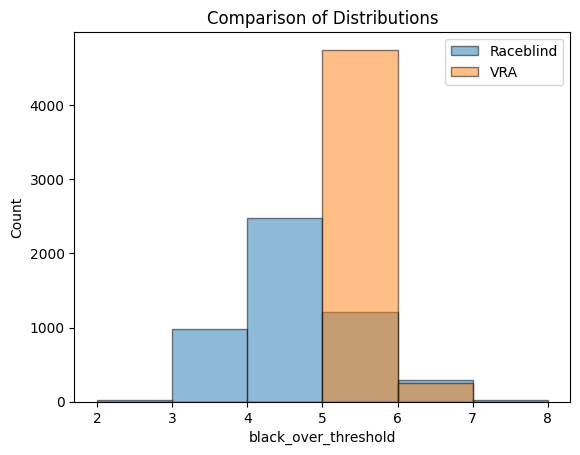

In [ ]:
raceblind_data = []
for k, v in raceblind_black_freq.items():
    raceblind_data.extend([k] * v)

vra_data = []
for k, v in vra_black_freq.items():
    vra_data.extend([k] * v)

# Plot
plt.hist(raceblind_data, bins=range(2, 9), alpha=0.5, label='Raceblind', edgecolor='black')
plt.hist(vra_data, bins=range(2, 9), alpha=0.5, label='VRA', edgecolor='black')

plt.xlabel('black_over_threshold')
plt.ylabel('Count')
plt.legend()
plt.title('Comparison of Distributions')
plt.show()

## Export

In [ ]:
raceblind_results_df.to_csv('output/Georgia/minority_effective_score/ga_rb_minority_effective_score_cnt.csv', index=False)
raceblind_scores_df.to_csv('output/Georgia/minority_effective_score/ga_rb_minority_effective_scores.csv', index=False)

In [ ]:
vra_results_df.to_csv('output/Georgia/minority_effective_score/ga_vra_minority_effective_score_cnt.csv', index=False)
vra_scores_df.to_csv('output/Georgia/minority_effective_score/ga_vra_minority_effective_scores.csv', index=False)

# Calculate Minority Population Percentage per Random District
- For each random district in a random district plan, calculate the minority population percentage for each minority that is feasible in the state. 
- Also, determine if that population percentage exceeds the minority population percentage threshold.

## Raceblind

In [30]:
raceblind_pop_pct = []
raceblind_pop_cnt = []
for i, plan in enumerate(raceblind_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    black_pct = district_stats['Black_population']/district_stats['Total_population']
    latino_pct = district_stats['Latino_population']/district_stats['Total_population']
    black_count_over_50 = (black_pct > 0.5).sum()
    latino_count_over_50 = (latino_pct > 0.5).sum()

    raceblind_pop_pct.append({
        "plan_id": i,
        "black_pct": black_district_effective,
        "latino_pct": latino_district_effective,
    })
    
    raceblind_pop_cnt.append({
        "plan_id": i,
        "black_cnt": black_count_over_50,
        "latino_cnt": latino_count_over_50,
    })

In [31]:
raceblind_pop_pct_df = pd.DataFrame(raceblind_pop_pct)

In [32]:
raceblind_pop_cnt_df = pd.DataFrame(raceblind_pop_cnt)

In [29]:
raceblind_pop_pct_df

,plan_id,black_pct,latino_pct
0,0,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
1,1,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
2,2,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
3,3,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
4,4,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
...,...,...,...
4995,4995,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
4996,4996,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
4997,4997,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."
4998,4998,"{1: 0, 2: 0.8401135040426965, 3: 0, 4: 1, 5: 0...","{1: 0, 2: 0.0847576082328448, 3: 0, 4: 0.08483..."


In [35]:
raceblind_pop_cnt_df

,plan_id,black_cnt,latino_cnt
0,0,4,0
1,1,3,0
2,2,3,0
3,3,3,0
4,4,3,0
...,...,...,...
4995,4995,2,0
4996,4996,2,0
4997,4997,2,0
4998,4998,2,0


In [36]:
raceblind_black_pop_freq = raceblind_pop_cnt_df["black_cnt"].value_counts().sort_index()
raceblind_black_pop_freq

black_cnt
0       4
1     790
2    3646
3     559
4       1
Name: count, dtype: int64

In [41]:
raceblind_latino_pop_freq = raceblind_pop_cnt_df["latino_cnt"].value_counts().sort_index()
raceblind_latino_pop_freq

latino_cnt
0    5000
Name: count, dtype: int64

## VRA

In [58]:
vra_pop_pct = []
vra_pop_cnt = []
for i, plan in enumerate(vra_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    black_pct = district_stats['Black_population']/district_stats['Total_population']
    latino_pct = district_stats['Latino_population']/district_stats['Total_population']
    black_count_over_50 = (black_pct > 0.5).sum()
    latino_count_over_50 = (latino_pct > 0.5).sum()

    vra_pop_pct.append({
        "plan_id": i,
        "black_pct": black_district_effective,
        "latino_pct": latino_district_effective,
    })
    
    vra_pop_cnt.append({
        "plan_id": i,
        "black_cnt": black_count_over_50,
        "latino_cnt": latino_count_over_50,
    })

In [59]:
vra_pop_pct_df = pd.DataFrame(vra_pop_pct)
vra_pop_cnt_df = pd.DataFrame(vra_pop_cnt)

In [60]:
vra_black_pop_freq = vra_pop_cnt_df["black_cnt"].value_counts().sort_index()
vra_black_pop_freq

black_cnt
0       5
1    1672
2    2827
3     463
4      33
Name: count, dtype: int64

In [61]:
vra_latino_pop_freq = vra_pop_cnt_df["latino_cnt"].value_counts().sort_index()
vra_latino_pop_freq

latino_cnt
0    5000
Name: count, dtype: int64

## Raceblind vs. VRA

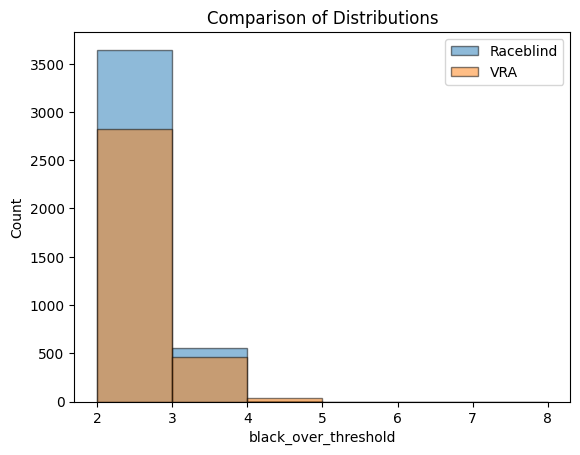

In [ ]:
raceblind_data = []
for k, v in raceblind_black_pop_freq.items():
    raceblind_data.extend([k] * v)

vra_data = []
for k, v in vra_black_pop_freq.items():
    vra_data.extend([k] * v)

# Plot
plt.hist(raceblind_data, bins=range(2, 9), alpha=0.5, label='Raceblind', edgecolor='black')
plt.hist(vra_data, bins=range(2, 9), alpha=0.5, label='VRA', edgecolor='black')

plt.xlabel('black_over_threshold')
plt.ylabel('Count')
plt.legend()
plt.title('Comparison of Distributions')
plt.show()

## Export 

In [ ]:
raceblind_pop_pct_df.to_csv('output/Georgia/population_pct/ga_rb_pop_pct.csv', index=False)
raceblind_pop_cnt_df.to_csv('output/Georgia/population_pct/ga_rb_pop_cnt.csv', index=False)

In [ ]:
vra_pop_pct_df.to_csv('output/Georgia/population_pct/ga_vra_pop_pct.csv', index=False)
vra_pop_cnt_df.to_csv('output/Georgia/population_pct/ga_vra_pop_cnt.csv', index=False)

# Calculate Republican/Democratic split for each random district plan
- For each generated plan in an ensemble, estimate the Republican/Democratic votes in each district. Since each district is a collection of precincts, use the historic precinct vote totals (e.g., 2024 Presidential) to estimate the winner of an election in each district.

In [70]:
TOTAL_DISTRICT = 14

## Raceblind

In [77]:
raceblind_splits = []
for i, plan in enumerate(raceblind_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    kamala = 0
    for _, district in district_stats.iterrows():
        if district['Kamala D. Harris'] > district['Donald J. Trump']:
            kamala+=1

    raceblind_splits.append({
        "plan_id": i,
        "democrat": kamala,
        "republican": TOTAL_DISTRICT-kamala,
    })

In [78]:
raceblind_splits_df = pd.DataFrame(raceblind_splits)
raceblind_splits_df

,plan_id,democrat,republican
0,0,5,9
1,1,5,9
2,2,5,9
3,3,5,9
4,4,5,9
...,...,...,...
4995,4995,5,9
4996,4996,5,9
4997,4997,5,9
4998,4998,5,9


In [79]:
raceblind_democrat = raceblind_splits_df["democrat"].value_counts().sort_index()
print(raceblind_democrat)

democrat
3      38
4     620
5    2004
6    1636
7     631
8      71
Name: count, dtype: int64


In [87]:
raceblind_democrat_df = raceblind_democrat.reset_index()
raceblind_democrat_df.columns = ["democrat", "count"]

raceblind_democrat_df.head()

,democrat,count
0,3,38
1,4,620
2,5,2004
3,6,1636
4,7,631


## VRA

In [80]:
vra_splits = []
for i, plan in enumerate(vra_plans):
    gdf_plan = gdf.merge(plan, on="UNIQUE_ID")
    gdf_plan = gdf_plan.drop(columns=['District_x'])
    gdf_plan = gdf_plan.rename(columns={'District_y': 'District'})
    district_stats = gdf_plan.groupby("District").sum(numeric_only=True).reset_index()
    kamala = 0
    for _, district in district_stats.iterrows():
        if district['Kamala D. Harris'] > district['Donald J. Trump']:
            kamala+=1

    vra_splits.append({
        "plan_id": i,
        "democrat": kamala,
        "republican": TOTAL_DISTRICT-kamala,
    })

In [81]:
vra_splits_df = pd.DataFrame(vra_splits)
vra_splits_df

,plan_id,democrat,republican
0,0,5,9
1,1,6,8
2,2,6,8
3,3,6,8
4,4,6,8
...,...,...,...
4995,4995,6,8
4996,4996,6,8
4997,4997,6,8
4998,4998,6,8


In [ ]:
vra_democrat = vra_splits_df["democrat"].value_counts().sort_index()
print(vra_democrat)

democrat
5    2366
6    2410
7     223
8       1
Name: count, dtype: int64


In [88]:
vra_democrat_df = vra_democrat.reset_index()
vra_democrat_df.columns = ["democrat", "count"]

vra_democrat_df.head()

,democrat,count
0,5,2366
1,6,2410
2,7,223
3,8,1


## Raceblind vs. VRA

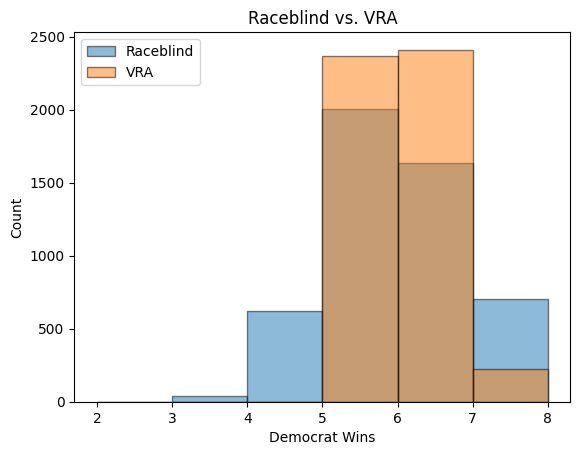

In [83]:
raceblind_data = []
for k, v in raceblind_democrat.items():
    raceblind_data.extend([k] * v)

vra_data = []
for k, v in vra_democrat.items():
    vra_data.extend([k] * v)

# Plot
plt.hist(raceblind_data, bins=range(2, 9), alpha=0.5, label='Raceblind', edgecolor='black')
plt.hist(vra_data, bins=range(2, 9), alpha=0.5, label='VRA', edgecolor='black')

plt.xlabel('Democrat Wins')
plt.ylabel('Count')
plt.legend()
plt.title('Raceblind vs. VRA')
plt.show()

## Export

In [90]:
raceblind_democrat_df.to_csv('output/Georgia/splits/raceblind_democrat_wins.csv', index=False)
vra_democrat_df.to_csv('output/Georgia/splits/vra_democrat_wins.csv', index=False)

In [100]:
raceblind_splits_df.to_csv('output/Georgia/splits/raceblind_splits.csv', index=False)
vra_splits_df.to_csv('output/Georgia/splits/vra_splits.csv', index=False)

# Calculate ensemble measures
- Calculate the summary measures for each ensemble. At a minimum, measures will include the number of district plans, and for each plan, Republican/Democratic splits, number of minority effective districts, and the number of opportunity districts (i.e., majority-minority districts).

## Raceblind

In [111]:
raceblind_minority_effective = pd.read_csv('output/Georgia/minority_effective_score/ga_rb_minority_effective_score_cnt.csv')
raceblind_opportunity = pd.read_csv('output/Georgia/population_pct/ga_rb_pop_cnt.csv')
raceblind_splits = pd.read_csv('output/Georgia/splits/raceblind_splits.csv')

In [112]:
print(f"minority_effective:{raceblind_minority_effective.columns}")
print(f"opportunity:{raceblind_opportunity.columns}")
print(f"splits: {raceblind_splits.columns}")

minority_effective:Index(['plan_id', 'black_over_threshold', 'latino_over_threshold'], dtype='object')
opportunity:Index(['plan_id', 'black_cnt', 'latino_cnt'], dtype='object')
splits: Index(['plan_id', 'democrat', 'republican'], dtype='object')


In [113]:
minority_df = raceblind_minority_effective.copy()
opportunity_df = raceblind_opportunity.copy()
splits_df = raceblind_splits.copy()


In [114]:
minority_df["minority_effective"] = (
    minority_df["black_over_threshold"] +
    minority_df["latino_over_threshold"]
)
minority_df.head()


,plan_id,black_over_threshold,latino_over_threshold,minority_effective
0,0,5,0,5
1,1,5,0,5
2,2,5,0,5
3,3,5,0,5
4,4,4,0,4


In [ ]:
opportunity_df["opportunity_districts"] = (
    opportunity_df["black_cnt"] +
    opportunity_df["latino_cnt"]
)
opportunity_df.head()


,plan_id,black_cnt,latino_cnt,opportunity_districts
0,0,4,0,4
1,1,3,0,3
2,2,3,0,3
3,3,3,0,3
4,4,3,0,3


In [ ]:
raceblind_summary = splits_df.merge(
    minority_df[["plan_id", "minority_effective"]],
    on="plan_id",
    how="inner"
).merge(
    opportunity_df[["plan_id", "opportunity_districts"]],
    on="plan_id",
    how="inner"
)

In [117]:
raceblind_summary["ensemble"] = "raceblind"

print(raceblind_summary.shape)

(5000, 6)


In [118]:
raceblind_summary.head()

,plan_id,democrat,republican,minority_effective,opportunity_districts,ensemble
0,0,5,9,5,4,raceblind
1,1,5,9,5,3,raceblind
2,2,5,9,5,3,raceblind
3,3,5,9,5,3,raceblind
4,4,5,9,4,3,raceblind


## VRA

In [119]:
vra_minority_effective = pd.read_csv('output/Georgia/minority_effective_score/ga_vra_minority_effective_score_cnt.csv')
vra_opportunity = pd.read_csv('output/Georgia/population_pct/ga_vra_pop_cnt.csv')
vra_splits = pd.read_csv('output/Georgia/splits/vra_splits.csv')

In [120]:
vra_minority_df = vra_minority_effective.copy()
vra_opportunity_df = vra_opportunity.copy()
vra_splits_df = vra_splits.copy()


In [121]:
vra_minority_df["minority_effective"] = (
    vra_minority_df["black_over_threshold"] +
    vra_minority_df["latino_over_threshold"]
)
vra_minority_df.head()


,plan_id,black_over_threshold,latino_over_threshold,minority_effective
0,0,5,0,5
1,1,5,0,5
2,2,5,0,5
3,3,5,0,5
4,4,5,0,5


In [122]:
vra_opportunity_df["opportunity_districts"] = (
    vra_opportunity_df["black_cnt"] +
    vra_opportunity_df["latino_cnt"]
)
vra_opportunity_df.head()

,plan_id,black_cnt,latino_cnt,opportunity_districts
0,0,4,0,4
1,1,4,0,4
2,2,4,0,4
3,3,4,0,4
4,4,4,0,4


In [123]:
vra_summary = vra_splits_df.merge(
    vra_minority_df[["plan_id", "minority_effective"]],
    on="plan_id",
    how="inner"
).merge(
    vra_opportunity_df[["plan_id", "opportunity_districts"]],
    on="plan_id",
    how="inner"
)

In [125]:
vra_summary['ensemble'] = 'VRA'

In [126]:
print(vra_summary.shape)

(5000, 6)


In [127]:
vra_summary.head()

,plan_id,democrat,republican,minority_effective,opportunity_districts,ensemble
0,0,5,9,5,4,VRA
1,1,6,8,5,4,VRA
2,2,6,8,5,4,VRA
3,3,6,8,5,4,VRA
4,4,6,8,5,4,VRA


## Validity Check

### VRA

In [147]:
vra_summary_democrat = vra_summary['democrat'].value_counts().sort_index()
print(vra_summary_democrat)
print(vra_democrat)

democrat
5    2366
6    2410
7     223
8       1
Name: count, dtype: int64
democrat
5    2366
6    2410
7     223
8       1
Name: count, dtype: int64


In [144]:
vra_summary_minority = vra_summary['minority_effective'].value_counts().sort_index()
print(vra_summary_minority)
print(vra_black_freq)

minority_effective
5    4752
6     248
Name: count, dtype: int64
black_over_threshold
5    4752
6     248
Name: count, dtype: int64


In [146]:
vra_summary_opportunity = vra_summary['opportunity_districts'].value_counts().sort_index()
print(vra_summary_opportunity)
print(vra_black_pop_freq)

opportunity_districts
0       5
1    1672
2    2827
3     463
4      33
Name: count, dtype: int64
black_cnt
0       5
1    1672
2    2827
3     463
4      33
Name: count, dtype: int64


### Raceblind

In [148]:
rb_summary_democrat = raceblind_summary['democrat'].value_counts().sort_index()
print(rb_summary_democrat)
print(raceblind_democrat)

democrat
3      38
4     620
5    2004
6    1636
7     631
8      71
Name: count, dtype: int64
democrat
3      38
4     620
5    2004
6    1636
7     631
8      71
Name: count, dtype: int64


In [149]:
rb_summary_minority = raceblind_summary['minority_effective'].value_counts().sort_index()
print(rb_summary_minority)
print(raceblind_black_freq)

minority_effective
2      19
3     980
4    2477
5    1215
6     287
7      22
Name: count, dtype: int64
black_over_threshold
2      19
3     980
4    2477
5    1215
6     287
7      22
Name: count, dtype: int64


In [150]:
rb_summary_opportunity = raceblind_summary['opportunity_districts'].value_counts().sort_index()
print(rb_summary_opportunity)
print(raceblind_black_pop_freq)

opportunity_districts
0       4
1     790
2    3646
3     559
4       1
Name: count, dtype: int64
black_cnt
0       4
1     790
2    3646
3     559
4       1
Name: count, dtype: int64


## Export

In [151]:
vra_summary.to_csv('output/Georgia/ensemble_summary/vra_summary.csv', index=False)
raceblind_summary.to_csv('output/Georgia/ensemble_summary/raceblind_summary.csv', index=False)